# A most `British' topic: Queueing theory

## What is queueing theory?

Queues are all around us - they are part of modern life. Queueing theory is the study of queues via a mathematical description. It enables us to model, study and understand how service processes work, and importantly provide a framework with which we can learn what makes systems run smoothly or grind to a halt.

## Queues to describe systems
Processes and systems consist can be thought of consisting of "customers" and "servers" or "arrivals" and "service (departure)". 
- **Customers** seek some kind of service and placing a demand upon the resource,
- Customers **arrive according to some process**,
- If **a server** is available, the customer enters service,
- The time it takes to serve them, **the service time** is defined by some process, 
- When there is a **limited serving resource**, e.g. a finite number of servers,... 
- That is -- **variable demand can exceed the service capacity**, and a queue forms when all servers are busy.
- Queues become ``unpredictable'' in their size if arrivals and service times are random.

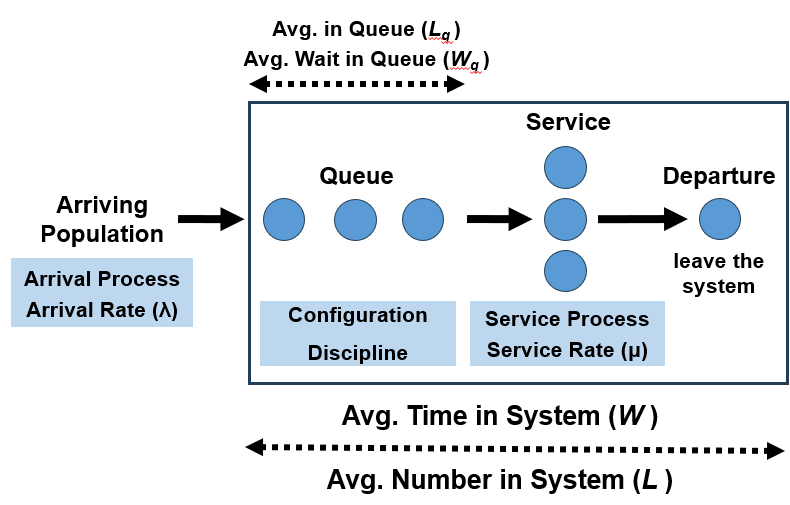

## Why study healthcare systems in this way?
 Healthcare systems are often complex, interconnected and convoluted. Customers here are patients, seeking service to diagnose, maintain or improve their health/quality of life. 
 No two patients are alike in reality (e.g. different life contexts, illnesses/morbidities, different views on what quality of life means for them).
 In this view, the services are diverse (e.g. GP, A+E, specialised clinics) and so are the servers (e.g. different clinical roles, administrative etc).
 Finally, how patients use these different services varies (e.g. random walk-ins, appointments, periodic treatment etc).
 And as such:
- Small changes in one part of the system greatly affects the rest (most likely in unknown ways!),
- Also, changing a system in real life is expensive, unwieldy and impracticable.

ALL VERY COMPLEX! **BUT,  here is a beauty of mathematical modelling.**
Forming a queueing model of these systems, we can "generalise" patients and focus on their traits that influence the operation of a system as a whole.
We can also "generalise" the services and focus on their operation as a function of the constraints, demand and measures of interest. 
So, given a set of parameters/data/structure of a system, we can:
- identify how, why and where problem occur in the system,
And therefore seek to find scenarios which:
- minimize the inconveniences incurred,
- maximize the use of the limited resources,
- measure the performance, e.g.:
    - average time a resource is in use, or average time a customer must wait. 

Overall then the aim is to inform stakeholders about their system and problems, and provide (otherwise unavailable) insights into effective, informed decision making about how to change the system: increase serving capacity, speed up service times, or outside of healthcare, similar methods inform when to add a new runway to an airport perhaps.

# Making queueing models

Having identified our system of interest, who the customers are and the problems that occur in the system -- our next job as the Operational Researcher is to make the model!
But where do we start? First, import some packages, then let's consider the arrival process.

In [1]:
### Import packages for models below

## Import required packages
# importing poisson from scipy
from scipy.stats import poisson
from scipy.stats import expon

# importing numpy as np
import numpy as np

# importing matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

## Arrival processes
Let's first consider demand. Customer demand can be consider as an "arrival" to the system -- whether that is someone rocking up to a coffee shop, phoning for an appointment, trying to get concert tickets online -- as they try to access the system they are a new arrival.

This so-called arrival process can be **deterministic** (that is, known in time) or **stochastic** (that is, random/unknown in time). To truly know what is going on in a real world system, it is best to look at data and asking people who know the system!

For now, by way of example for us, let's consider the most common and simplest assumptions that researchers make. That is, consider the arrivals are **random** and therefore follow some probability distribution which defines the *likelihood* of when people arrive/seek service to a service according to:
- Customers arrive randomly in time, according to some rate $\lambda$ -- the mean arrival rate,
- The time between successive arrivals is given by $1/\lambda$, called the interarrival time,

We also make three further assumption to make the modelling "more tractable":
1. The time between the arrivals of customers are independent of each other,
2. Future arrivals do not depend on the past state of the system (there is a good mathematical and practical reason for this!).
3. Different arrival streams can be pooled (e.g. the arrivals of different customers can be simply summed).

These assumptions about the probability distribution then SCREAM that we should use a ***Poisson distribution***:
$$A(t) \sim \text{Pois}(\lambda t), \; \text{ such that } \text{Prob}(A(t) = n) = \exp(-\lambda t)\frac{(\lambda t)^n}{n!},$$

Formally, a Poisson process is a counting process (i.e. integer values) that counts the number of events that occur in an amount of time $t$, such that:
	$$
    \begin{align*}
		&N(0) = 0, \\
		&N(t) \geq 0, \\
		&N(t_2) \geq N(t_1), \text{ for } t_2 > t_1, \\
		&\begin{aligned}
			\text{Prob}(A(t + s) - A(t) = k) = exp(-\lambda t)\frac{(\lambda t)^k}{k!}, &\text{ time between two events are independent} \\
			&\text{and identically distributed}.
	    \end{aligned}
    \end{align*}
    $$


### QUESTION
Let's plot it! Feel free to play with value of $\lambda$ - denoted 'lam' below - and see what the plots look like!

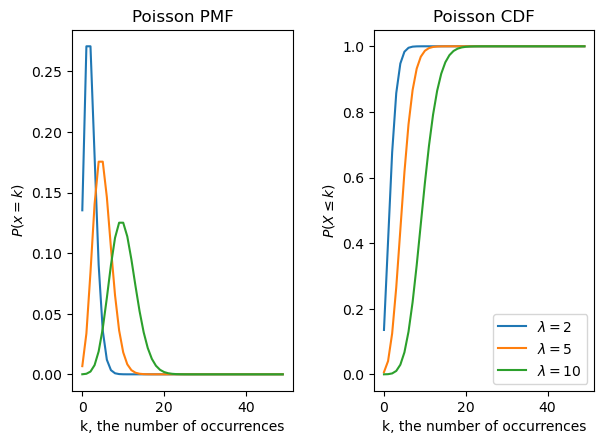

In [2]:
## Assign lambda values:
lam = np.array([2,5,10])

# creating a numpy array for x-axis
# using step size as 1
x = np.arange(0, 50, 1)

# poisson distribution data for y-axis
y11 = poisson.pmf(x, mu=lam[0], loc=0)
y12 = poisson.pmf(x, mu=lam[1], loc=0)
y13 = poisson.pmf(x, mu=lam[2], loc=0)

y21 = poisson.cdf(x, mu=lam[0], loc=0)
y22 = poisson.cdf(x, mu=lam[1], loc=0)
y23 = poisson.cdf(x, mu=lam[2], loc=0)

# plotting the graph
figure, axis = plt.subplots(1, 2)
axis[0].plot(x, y11)
axis[0].plot(x, y12)
axis[0].plot(x, y13)
axis[0].set_title("Poisson PMF")
axis[0].set_xlabel("k, the number of occurrences")
axis[0].set_ylabel("$P(x = k)$")

axis[1].plot(x, y21)
axis[1].plot(x, y22)
axis[1].plot(x, y23)
axis[1].set_title("Poisson CDF")
axis[1].set_xlabel("k, the number of occurrences")
axis[1].set_ylabel("$P(X \\leq k)$")
axis[1].legend(['$\\lambda = $'+str(lam[0]),'$\\lambda = $'+str(lam[1]),'$\\lambda = $'+str(lam[2])])
figure.tight_layout(pad=2.0)
# showing the graph
plt.show()

An alternative method...plotting a 'realisation' of the Poisson distribution e.g. random data distributed according to a Poisson Distribution.

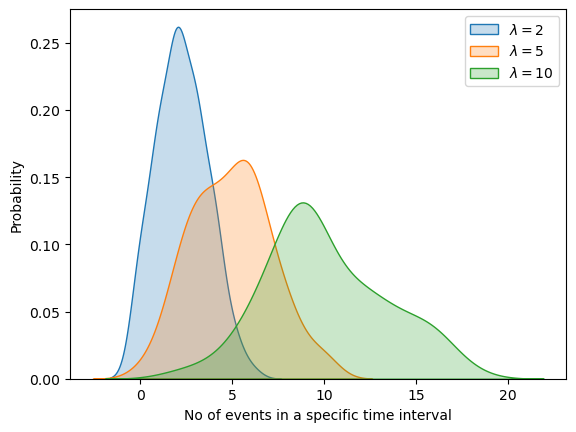

In [3]:
#Generating Poisson data
sample1 = poisson.rvs(mu=lam[0], size=100)
sample2 = poisson.rvs(mu=lam[1], size=100)
sample3 = poisson.rvs(mu=lam[2], size=100)

#Plotting Poisson Distribution using Seaborn
sns.kdeplot(x=sample1, fill=True, label='$\\lambda = $'+str(lam[0]))
sns.kdeplot(x=sample2, fill=True, label='$\\lambda = $'+str(lam[1]))
sns.kdeplot(x=sample3, fill=True, label='$\\lambda = $'+str(lam[2]))
plt.xlabel('No of events in a specific time interval')
plt.ylabel('Probability')
plt.legend()
plt.show()

## BUT why do those assumptions SCREAM a Poisson Process?

There are three assumptions made above - let's see why they are helpful:

### 1. The independent, inter-arrival rates of customers are Exponentially distributed.
To see this, let $t_A$ be the time at which the first arrival occurs, e.g. the next arrival after some time $s$. Then,
$$ \begin{equation*}
	\text{Prob}(t_A > t) = \text{Prob}\left(\text{no arrival occurs in } \left(0,t\right]\right) = \exp(-\lambda \ t).
\end{equation*} $$

that is, the probability no one arrives in time $t$. Alternatively, if we are interested in the event that someone arrives within time $t$, say $B(t)$, we can use our favourite probability trick:
$$\begin{equation*}
	B(t) = \text{Prob}(t_A \leq t) = 1 - \text{Prob}(t_A > t) = 1 - \exp(-\lambda \ t).
\end{equation*}$$

Crucially, the above process is known as the probability distribution function of the Exponential distribution with mean $1/\lambda$, and therefore we can write:
$$\begin{align*}
	B(t) \sim \text{Exp}(\lambda), \; B(t) = \begin{cases} 
		1 - \exp(-\lambda \ t), \; t \geq 0, \\
		0, \; \text{otherwise}.
	\end{cases}
\end{align*}$$

Average arrival time: [0.5374683398743594, 0.20290383046659466, 0.09417442036120172]...


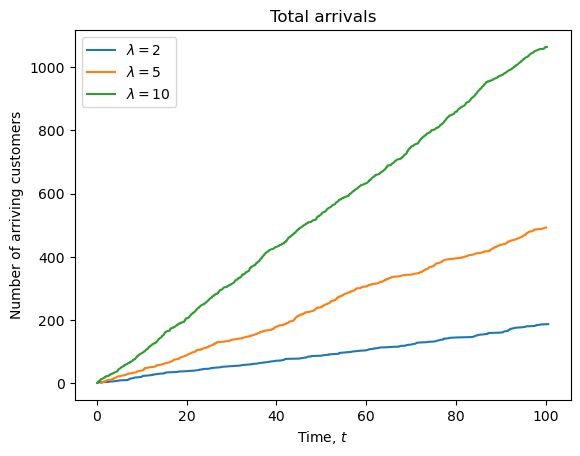

In [4]:
duration = 100
clock = 0

arrivals = 0
avg_time = [0,0,0]

for i in [0,1,2]:
    interarr = []
    arr = []
    systime = []
    clock = 0
    arrivals = 0
    while clock <= duration:
        next_arr = np.random.exponential(1./lam[i])
        clock += next_arr
        arrivals += 1
        interarr.append(next_arr)
        arr.append(arrivals)
        systime.append(clock)
    avg_time[i] = np.mean(interarr)
    figure
    plt.plot(systime,arr)

plt.title("Total arrivals")
plt.xlabel("Time, $t$")
plt.ylabel("Number of arriving customers")
plt.legend(['$\\lambda = $'+str(lam[0]),'$\\lambda = $'+str(lam[1]),'$\\lambda = $'+str(lam[2])])

print('Average arrival time: %r...' % avg_time)

### 2. The arrivals are Markovian - Memoryless interarrival times.

***A memoryless property:*** future changes in the system are independent of the system's past. 
    
Find the probability of a new arrival within $t$, given no previous arrivals occurred in the previous $s$:

$$\begin{align*}
	\begin{aligned}
		\text{Prob}(T > t + s | T > s) & = \frac{\text{Prob}(T > s+t \cap T > s)}{\text{Prob}(T > s)} \text{ (by Bayes' theorem)},  \\
		& = \frac{\text{Prob}(T > s+t \cap T > s)}{\text{Prob}(T > s)}  \text{ (since $s + t > s$)}, \\
		& = \frac{\exp(-\lambda(t + s))}{\exp(-\lambda s)}, \\
		& = \exp(-\lambda t), \\
		& = \text{Prob}(T > t).
	\end{aligned}
\end{align*}$$

i.e. the probability of a future arrival in a time $t$ is unchanged by the what occurred previously.

This means that the "next arrival time" can be randomly evaluated at any point as follows:
```
next_arr = np.random.exponential(1./lam[i])
```
rather than as a function of current system time. So we only consider the time to next arrival - this helps mathematically for both analytical and simulation models.

### QUESTION:
Let $N(t)$ be a Poisson process with intensity $\lambda=2$, and let $X_1, X_2, \dots$ be the corresponding interarrival times.
1. Find the probability that the first arrival occurs after $t=0.5$, i.e., $P(X_1>0.5)$.

2. Given that we have had no arrivals before $t=1$, find $P(X_1>3)$.

3. Given that the third arrival occurred at time $t = 2$, find the probability that the fourth arrival occurs after $t = 4$.

1. Let $N(t)$ be a Poisson process with intensity $\lambda=2$, and let $X_1, X_2, \dots$ be the corresponding interarrival times.

   **Solution**:
   
   Find the probability that the first arrival occurs after $t=0.5$, i.e., $P(X_1>0.5)$.
   Since $X_1 \sim Exponential(2)$, we can write

$$\begin{align*}
    P(X_1>0.5) &=e^{-(2 \times 0.5)} \\
    &\approx 0.37
  \end{align*}$$


In [5]:
#As code:
from scipy.stats import expon
1-expon.cdf(x=0.5, scale=1/2)

0.36787944117144233

2. Given that we have had no arrivals before $t=1$, find $P(X_1>3)$.
   
   **Solution**:
   
   Another way to solve this is to note that the number of arrivals in $(1,3]$ is independent of the arrivals before $t = 1$. Thus, 
$$
\begin{align*}
    P(X_1>3|X_1>1) &=P\big(\textrm{no arrivals in }(1,3] \; | \; \textrm{no arrivals in }(0,1]\big)\\
    &=P\big(\textrm{no arrivals in }(1,3]\big)\; (\textrm{independent increments})\\
    &=e^{-2 \times 2}\\
    &\approx 0.0183
  \end{align*}
$$

In [6]:
#As code:
from scipy.stats import expon
1-expon.cdf(x=2, scale=1/2)

0.01831563888873422

3. Given that the third arrival occurred at time $t = 2$, find the probability that the fourth arrival occurs after $t = 4$.

   **Solution**:

    The time between the third and the fourth arrival is $X_4 ∼ Exponential(2)$. Thus, the desired conditional probability is equal to 
    $$
    \begin{align*}
        P(X_4>2|X_1+X_2+X_3=2)&=P(X_4>2) \; (\textrm{independence of the $X_i$'s})\\
        &=e^{-2 \times 2}\\
        &\approx 0.0183
      \end{align*}
    $$

In [7]:
#As code:
from scipy.stats import expon
1-expon.cdf(x=2, scale=1/2)

0.01831563888873422

### 3. Pooling of Poisson processes
Different types of customers, (aka customer classes is the usual connotation) may have their own probability distribution function to describe their arrival process. If, for example, there are $C$ different types of customer who each arrive to a service via independent Poisson processes of rate $\lambda_c, \ c = 1,2,...,C$, the total  arrivals can be pooled into one, uniform pooled stream with arrival rate: 
$$\lambda = \sum_{c=1}^C \lambda_c.$$
The reverse is also true -- an arrival process of rate $\lambda$ can be decomposed into multiple, $C$ independent streams of arrivals, where the probability that a customer from arrives and belongs to a certain stream is given by $p_c, \ c = 1,2,...,C$, such that:
$$\lambda = \sum_{c=1}^C p_c \lambda = \sum_{c=1}^C \lambda_c , \ \text{where } \sum_{c = 1}^C p_c = 1.$$

## Service Process
Just like the arrival process, `service' is described by a rate giving the number of customers served per unit time. That is, for some probability distribution that governs the service of customer, say $B(t)$:
1. the mean number of customers served per unit time (the mean service rate) is denoted $\mu$;
2. the mean time between successive completed service (the mean service time) is denoted $1/\mu$.

Note, that the service time is the length of time spent in service -- not including time spent waiting in the queue.
The queue may also have a finite waiting space -- but that's for another day.

The simplest distribution to consider is the Exponential distribution since ***the memoryless property*** applies - therefore future service times are independent of the past:
$$
\begin{align*}
	& T  \sim \text{Exp}(\mu), \\
	& f(t,\mu) = \begin{cases}
		\lambda \exp(-\lambda x), & x \geq 0, \\
		0, & \text{otherwise,}
	\end{cases} \\
	& B(t) = \text{Prob}(T \leq t) = 1 - \exp(-\mu t), \text{ for } t \geq 0.
\end{align*}
$$	

It is possible the system has multiple servers providing service, in which case the total number of servers available at a queueing facility is denoted by $c$. With two possible scenarios arising $c > 1$:
1. Each server has its own queue. 
2. There are fewer queues than servers, e.g. a single queue for all servers.
It is possible (as with the arrival process) for different types of customer to have different service rates.

### QUESTION
Based on the code for the Poisson distribution, can you plot similar plots for the Exponential distribution.

HINT: you may need the following commands:
<details>

```
expon.pdf(x, scale=muval[0], loc=0)
expon.cdf(x, scale=muval[0], loc=0)
```
where ```scale = muval[0]``` is your chosen service rate $\mu$.

</details>

Let's plot the Exponential distribution here. Feel free to play with value of $\mu$ - denoted 'mu' below - and see what the plots look like!

The **Solution** code is given below 

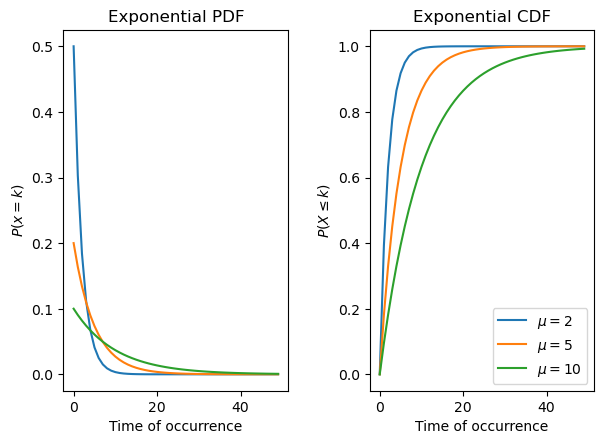

In [8]:
## Assign lambda values:
muval = np.array([2,5,10])

# creating a numpy array for x-axis
# using step size as 1
x = np.arange(0, 50, 1)

# poisson distribution data for y-axis
y11 = expon.pdf(x, scale=muval[0], loc=0)
y12 = expon.pdf(x, scale=muval[1], loc=0)
y13 = expon.pdf(x, scale=muval[2], loc=0)

y21 = expon.cdf(x, scale=muval[0], loc=0)
y22 = expon.cdf(x, scale=muval[1], loc=0)
y23 = expon.cdf(x, scale=muval[2], loc=0)

# plotting the graph
figure, axis = plt.subplots(1, 2)
axis[0].plot(x, y11)
axis[0].plot(x, y12)
axis[0].plot(x, y13)
axis[0].set_title("Exponential PDF")
axis[0].set_xlabel("Time of occurrence")
axis[0].set_ylabel("$P(x = k)$")

axis[1].plot(x, y21)
axis[1].plot(x, y22)
axis[1].plot(x, y23)
axis[1].set_title("Exponential CDF")
axis[1].set_xlabel("Time of occurrence")
axis[1].set_ylabel("$P(X \\leq k)$")
axis[1].legend(['$\\mu = $'+str(muval[0]),'$\\mu = $'+str(muval[1]),'$\\mu = $'+str(muval[2])])
figure.tight_layout(pad=2.0)
# showing the graph
plt.show()

An alternative method...plotting a 'realisation' of the Exponential distribution e.g. random data distributed according to an Exponential Distribution.

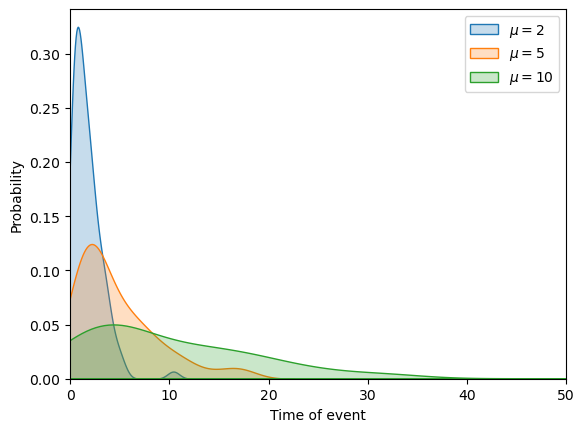

In [9]:
#Generating Exponential data
sample1 = expon.rvs(scale=muval[0], size=100)
sample2 = expon.rvs(scale=muval[1], size=100)
sample3 = expon.rvs(scale=muval[2], size=100)

#Plotting Poisson Distribution using Seaborn
sns.kdeplot(x=sample1, fill=True, label='$\\mu = $'+str(muval[0]))
sns.kdeplot(x=sample2, fill=True, label='$\\mu = $'+str(muval[1]))
sns.kdeplot(x=sample3, fill=True, label='$\\mu = $'+str(muval[2]))
plt.xlabel('Time of event')
plt.ylabel('Probability')
plt.legend()
plt.xlim(0, 50)
plt.show()

# Let's make some queues!
We are rarely interested in *just* arrivals or *just* departures alone. We want to be able to combine our knowledge about them to say something meaningful about the behaviour of a system aka a queue.

The simplest queues to analyse are those with Markovian arrivals and service times (as above!) - so now we have the building blocks ready, we can put it together.

Let's begin with just a single server system. The notation for this is an $M/M/1$ queue, where the two `$M$'s denote the Markovian nature of the arrivals and departures and the ‘$1$' denotes the number of servers.

For these queues we can write down analytical equations - which we will eventually look at.
For now, we look at simulating them first in the next Notebook.

### ASIDE:
#### Kendall's notation
A notation for quickly summarising a queueing model is as follows:
$$
\begin{equation*}
	A/D/c/K/N/D,
\end{equation*}
$$
- $A$: denotes the arrival process - examples include: 
    - $M$, for Markovian (Poisson);  
    - $M^x$, batch Markov process; 
    - $G$, general distribution,
- $D$: denotes the departure (service) process - examples include: 
    - $M$, for Markovian (Exponential);  
    - $M^x$, bulk Markov process; 
    - $G$, general distribution,
- $c$: the number of service channels (or servers),
- $K$: the number of places in the queue, its capacity. When the number is at this maximum, further arrivals are turned away. If infinite waiting space, drop the symbol.
- $N$: the calling population size, e.g. if finite, the arrival rate may depend on $N$,
- $D$: queue discipline:
    - FIFO/FCFS: first in first out/first come first serve,
	- LIFO/LCFS: last in first out/last come first serve,
	- SIRO: service in random order,
	- PQ: priority queueing (e.g. pre-emptive priority, class based),